In [15]:
import os
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt
from pyproj import Transformer
from glob import glob
import pickle

os.chdir('/store/carroll/col/data/2018/')

# %matplotlib widget

In [9]:
with open('/store/carroll/repos/chess-isofit/1_rccs/2018/bright_dark_fids.txt') as f:
    fids = [x.strip() for x in f.readlines()]

In [24]:
# subset imagery for apply_oe retrievals
output_dir = 'rccs/subsets_tmp/'
buf = 150

# get targets in utm 13n coords
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32613')
matterhorn_lot = transformer.transform(38.90306764650836, -106.96917819931046)
airpark = transformer.transform(38.85485376230754, -106.93336548979009)
coal_creek = transformer.transform(38.857671227274096, -107.09512257147314)

In [ ]:
for fid in fids:
    for x, y in [matterhorn_lot, airpark, coal_creek]:
        print(fid, x, y)
        
        # translate x, y to image coordinates
        fp_loc = glob(f'raw/L1/*/{fid}_rdn_ort_igm_ort.hdr')[0]
        loc = envi.open(fp_loc).open_memmap()
        rows, cols = loc[...,0].shape
        flat_x = loc[...,0].flatten()
        flat_y = loc[...,1].flatten()
        diff = np.abs(flat_x - x) + np.abs(flat_y - y)
        if np.min(diff) > 2: # check if target in fid
            print('skip')
            continue
        idx = np.argmin(diff)
        row, col = np.unravel_index(idx, (rows, cols))
    
        # rdn
        fp_rdn = glob(f'raw/L1/*/{fid}_rdn_ort.hdr')[0]
        fp_out = os.path.join(output_dir, f'{fid}_rdn.hdr')
        meta = envi.open(fp_rdn).metadata
        meta['lines'] = buf*2
        meta['samples'] = buf*2
        out_ds = envi.create_image(fp_out, meta, ext='', force=True)
        out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp_rdn).open_memmap()[row-buf:row+buf, col-buf:col+buf, :]
    
        # obs
        fp_obs = glob(f'raw/L1/*/{fid}_rdn_obs_ort.hdr')[0]
        fp_out = os.path.join(output_dir, f'{fid}_obs.hdr')
        meta = envi.open(fp_obs).metadata
        meta['lines'] = buf*2
        meta['samples'] = buf*2
        out_ds = envi.create_image(fp_out, meta, ext='', force=True)
        out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp_obs).open_memmap()[row-buf:row+buf, col-buf:col+buf, :]
    
        # loc
        fp_out = os.path.join(output_dir, f'{fid}_igm.hdr')
        meta = envi.open(fp_loc).metadata
        meta['lines'] = buf*2
        meta['samples'] = buf*2
        out_ds = envi.create_image(fp_out, meta, ext='', force=True)
        out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp_loc).open_memmap()[row-buf:row+buf, col-buf:col+buf, :]

In [46]:
# define the bbox for each target, set up empty dicts

targets = ['dark', 'bright']
px = {k1: {k2: {} for k2 in targets} for k1 in fids}
bboxes = {k1: {k2: {} for k2 in targets} for k1 in fids}

bboxes['NIS01_20180612_173258']['dark'] = [150, 160, 165, 175]
bboxes['NIS01_20180612_173258']['bright'] = [145, 147, 143, 147]

bboxes['NIS01_20180612_174155']['dark'] = [150, 160, 165, 175]
bboxes['NIS01_20180612_174155']['bright'] = [145, 147, 143, 147]

bboxes['NIS01_20180619_154149']['dark'] = [160, 170, 50, 60]
bboxes['NIS01_20180619_154149']['bright'] = [250, 255, 175, 180]

bboxes['NIS01_20180619_155226']['dark'] = [160, 170, 50, 60]
bboxes['NIS01_20180619_155226']['bright'] = [250, 255, 175, 180]

bboxes['NIS01_20180620_170133']['dark'] = [184, 186, 68, 70]
bboxes['NIS01_20180620_170133']['bright'] = [100, 105, 60, 65]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.039106786..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-401.77475..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.010136323..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008736126..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-919.1224..2.0].


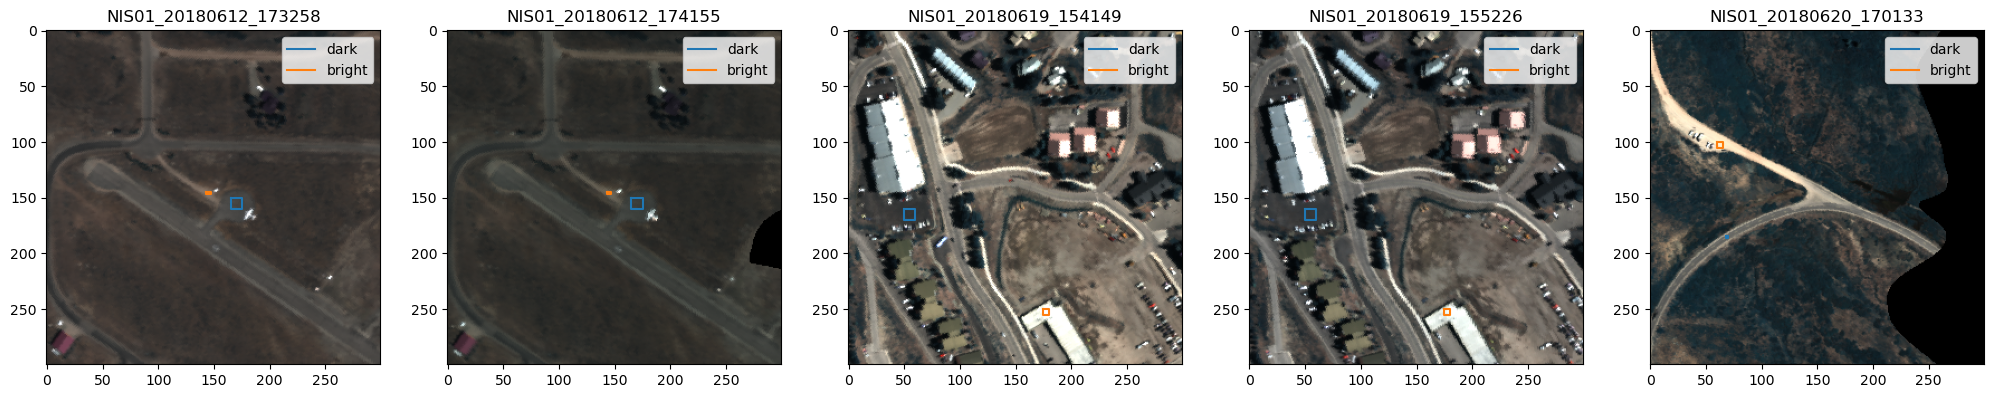

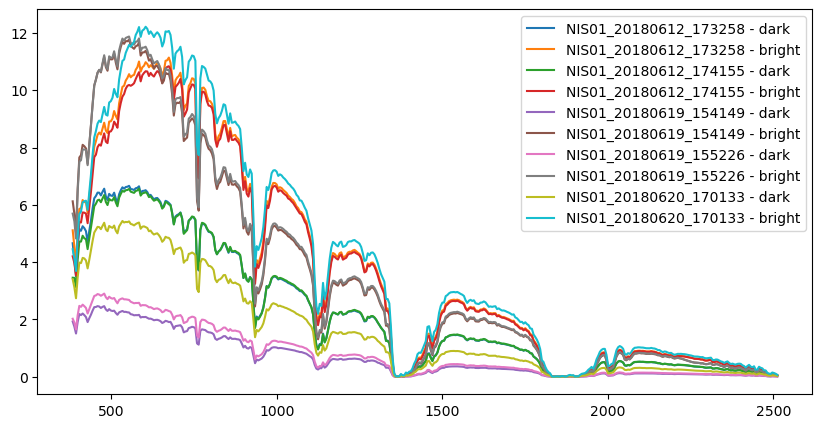

In [49]:
n_flights = len(fids)

fig, axs = plt.subplots(ncols=n_flights, figsize=(5*n_flights, 5))
for i in range(n_flights):
    flight = fids[i]
    for k in targets:
        row1, row2, col1, col2 = bboxes[flight][k]
        fp = glob(os.path.join(output_dir, f'{flight}_rdn.hdr'))[0]
        px[flight][k]['rdn'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
        fp = glob(os.path.join(output_dir, f'{flight}_obs.hdr'))[0]
        px[flight][k]['obs'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
        fp = glob(os.path.join(output_dir, f'{flight}_igm.hdr'))[0]
        px[flight][k]['loc'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
    
    fp = glob(os.path.join(output_dir, f'{flight}_rdn.hdr'))[0]
    wl = [float(x) for x in envi.read_envi_header(fp)['wavelength']]
    rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
    axs[i].imshow(rgb / np.max(rgb, axis=(0, 1))*2)
    for k, (row1, row2, col1, col2) in bboxes[flight].items():
        x = [col1, col2, col2, col1, col1]
        y = [row1, row1, row2, row2, row1]
        axs[i].plot(x, y, label=k)
    axs[i].legend()
    axs[i].set_title(flight)
plt.show()

# plot radiance
fig = plt.figure(figsize=(10,5))
for f in fids:
    for k in targets:
        plt.plot(wl, px[f][k]['rdn'], label=f'{f} - {k}')
plt.legend()
plt.show()

In [51]:
fp_out = os.path.join(output_dir, 'single_pxs_brightdark.pkl')
with open(fp_out, 'wb') as f:
    pickle.dump(px, f)